### Exercise 3. Inspect one informative bin

I chose the bin with ID: chr8_100000000_200000000.
Inspecting the histograms we can see that for Ovarian cancer start with many deletions and a low number of duplicates but with higher Mb we get more duplicate and less and less deletions. For the Glioblastoma the number of deletions and duplications seem to be roughly the same.
If we open the Progenetix collation plot we can clrarly see that the pattern matches the histograms for the Ovarian High Grade Serous Adenocarcinoma. At the start we have a lot more deletion than insertions (in the first histogram we see over 90 deletion samples and less than 20 duplication samples, like in the collation plot. And the last histogram shows more duplication and only few deletions. However the Glioblastoma is less coclusive, which coincides with the fact that chromosome 8 is not under the bins which favour Glioblastoma but in the ones favouring Ovarian High Grade Serous Adenocarcinoma. So at least for Ovarian High Grade Serous Adenocarcinoma we can say that he broad group-level pattern seems consistent with the model result.

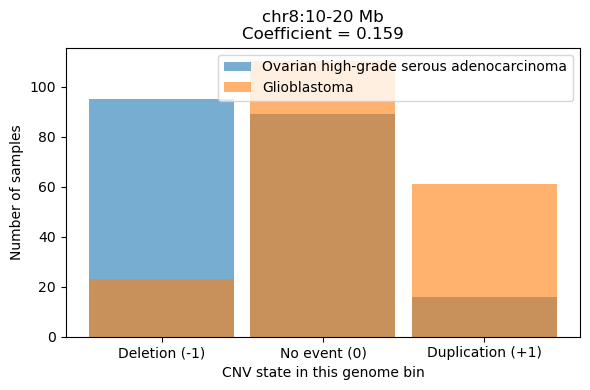

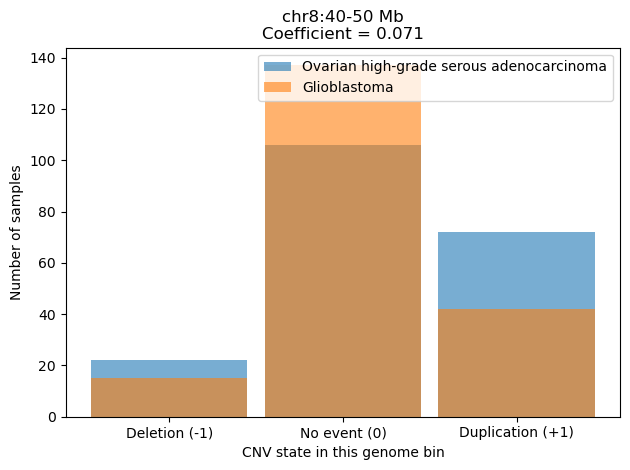

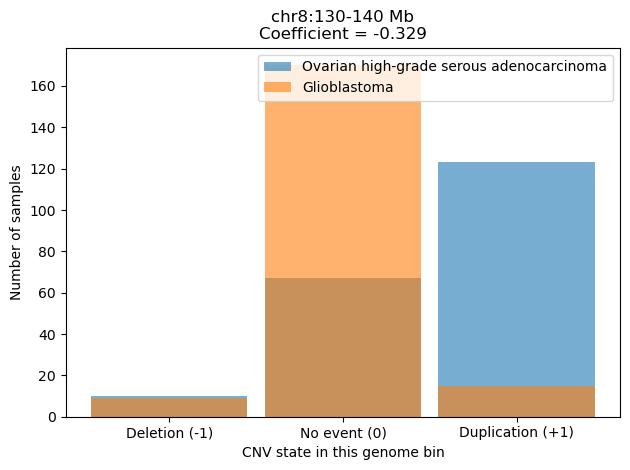

In [80]:

ids=["chr8_10000000_20000000", "chr8_40000000_50000000", "chr8_130000000_140000000"]
bin_id = "chr8_10000000_20000000"
plt.figure(figsize=(6, 4))

for bin_id in ids:

# Plot one histogram per class on the same axes.
    for group_code in [GROUP_1, GROUP_2]:
        values = plot_df.loc[plot_df["group_code"] == group_code, bin_id]
        plt.hist(
            values,
            bins=[-1.5, -0.5, 0.5, 1.5],
            alpha=0.6,
            label=GROUP_LABELS[group_code],
            rwidth=0.9,
        )

    coef_value = coefs[bin_id]
    plt.xticks([-1, 0, 1], ["Deletion (-1)", "No event (0)", "Duplication (+1)"])
    plt.xlabel("CNV state in this genome bin")
    plt.ylabel("Number of samples")
    plt.title(f"{format_bin_label(bin_id)}\nCoefficient = {coef_value:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Exercise 4. Download and interpret CNV frequency data

Now download the CNV frequency table for:

Example:
- `Small cell carcinoma, NOS`
- filter code: `pgx:icdom-80413`

Tasks:
- download the frequency table
- inspect its shape
- inspect its columns
- Explain why the frequency table has a different shape from the sample table.
    - what one row represents in the sample table
    - what one row represents in the frequency table
    - why these two tables cannot be merged row by row

In [58]:
frequency_urls = {
    "small_cell_carcinoma_icdom": "https://progenetix.org/services/intervalFrequencies/?output=pgxseg&filters=pgx:icdom-80413&limit=0"}

In [59]:
frequency_tables = {}

for source_query, url in frequency_urls.items():
    print(f"Downloading frequency table for {source_query}")
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    df_freq = pd.read_csv(StringIO(response.text), sep="\t", comment="#")
    df_freq["source_query"] = source_query
    frequency_tables[source_query] = df_freq

The shape of the frequency table is (3106, 7)

In [60]:
combined_frequency_df = pd.concat(
    [frequency_tables[source_query] for source_query in frequency_tables],
    ignore_index=True
)

combined_frequency_df.shape

(3106, 7)

In [61]:
frequency_tables["small_cell_carcinoma_icdom"].columns

Index(['reference_name', 'start', 'end', 'gain_frequency', 'loss_frequency',
       'no', 'source_query'],
      dtype='object')

In [62]:
combined_frequency_df.head()

,reference_name,start,end,gain_frequency,loss_frequency,no,source_query
0,1,0,400000,4.063,2.667,1,small_cell_carcinoma_icdom
1,1,400000,1400000,13.397,8.571,2,small_cell_carcinoma_icdom
2,1,1400000,2400000,13.016,9.841,3,small_cell_carcinoma_icdom
3,1,2400000,3400000,19.492,18.921,4,small_cell_carcinoma_icdom
4,1,3400000,4400000,17.778,16.698,5,small_cell_carcinoma_icdom


- One row in the sample table represents one biosample (one patient/tumor sample), with its metadata like diagnosis, tissue type, age, etc.

- One row in the frequency table is a genomic interval (a fixed-size region e.g., chromosome 1: 0–400,000 bp), with samples that show a gain or loss in that region.

- The two samples cant be merged by row as the two tables have fundamentally different structures. The sample table has one row per patient (N samples), while the frequency table has one row per genomic interval (thousands of bins). Even on a mathematic standpoint two tables cannot be merged if they dont have a shared attribute (column name), and those two tables dont share any common attribute.